<a href="https://colab.research.google.com/github/celinekm/CN/blob/main/anima%C3%A7%C3%A3ogauss_celine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NOME: CELINE KAZUMI MIYAJIMA RA: 176209

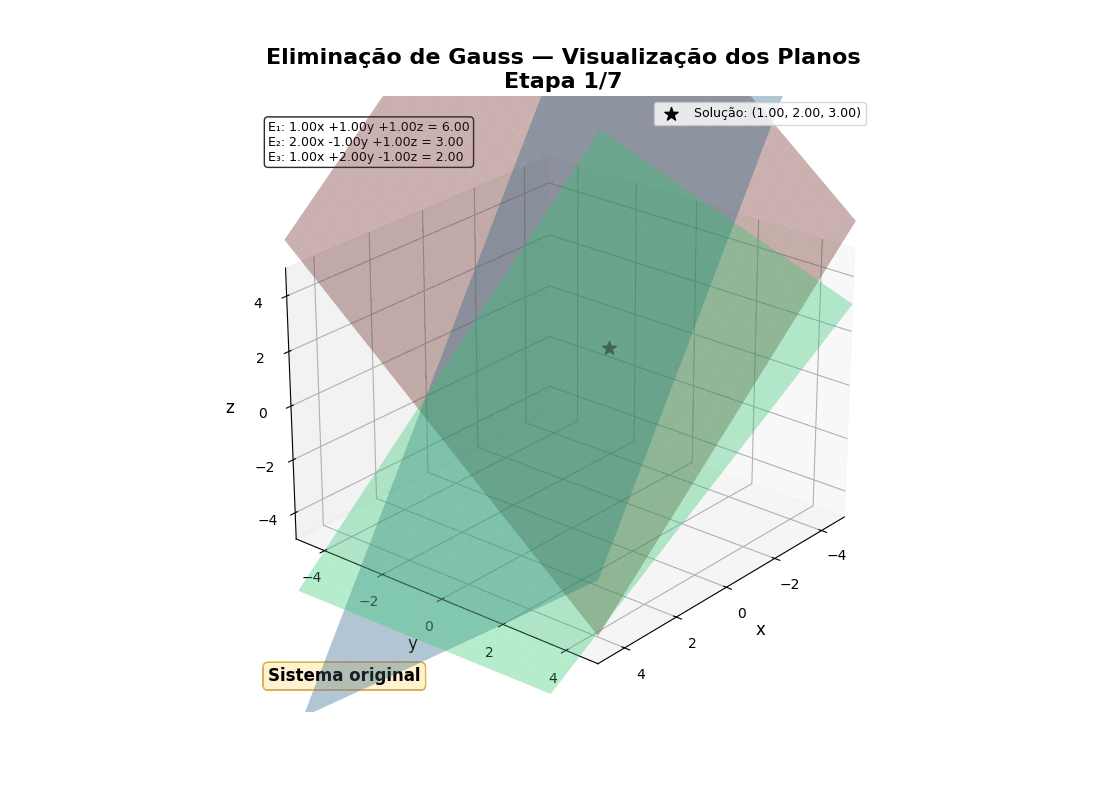

In [2]:
# ============================================================
# VISUALIZAÇÃO GEOMÉTRICA DA ELIMINAÇÃO DE GAUSS
# ============================================================
#
# Sistema:
#
# a11*x + a12*y + a13*z = b1
# a21*x + a22*y + a23*z = b2
# a31*x + a32*y + a33*z = b3
#
# Cada equação representa um plano no espaço 3D.
#
# Altere SOMENTE a matriz M.
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display


# ============================================================
# 1. MATRIZ DO SISTEMA
# ============================================================
#
# Formato:
#
# [ a11  a12  a13 | b1 ]
# [ a21  a22  a23 | b2 ]
# [ a31  a32  a33 | b3 ]
#
# ============================================================

M = np.array([
    [ 1,  1,  1,  6],
    [ 2, -1,  1,  3],
    [ 1,  2, -1,  2]
], dtype=float)


# ============================================================
# CONFIGURAÇÕES
# ============================================================

FPS = 1.2

NOME_GIF = "gauss_planos.gif"

# Limites dos eixos
LIMITE_X = (-5, 5)
LIMITE_Y = (-5, 5)
LIMITE_Z = (-5, 5)

TOL = 1e-10


# ============================================================
# 2. VERIFICAÇÃO
# ============================================================

if M.shape != (3, 4):
    raise ValueError(
        "A matriz precisa ter tamanho 3x4."
    )


# ============================================================
# 3. ELIMINAÇÃO DE GAUSS
# ============================================================

def gauss_passos(M, tol=1e-10):

    A = M.copy().astype(float)

    passos = []

    # --------------------------------------------------------
    # Estado inicial
    # --------------------------------------------------------

    passos.append({
        "matriz": A.copy(),
        "texto": "Sistema original",
        "pivo": None,
        "linha": None,
        "coluna": None
    })


    n = 3

    # --------------------------------------------------------
    # Eliminação
    # --------------------------------------------------------

    for k in range(n - 1):

        # -----------------------------------------------
        # Escolhe o maior pivô da coluna
        # -----------------------------------------------

        linha_pivo = k + np.argmax(
            np.abs(A[k:, k])
        )

        # Se não existe pivô
        if abs(A[linha_pivo, k]) < tol:
            continue


        # -----------------------------------------------
        # Troca de linhas
        # -----------------------------------------------

        if linha_pivo != k:

            A[[k, linha_pivo]] = \
                A[[linha_pivo, k]]

            passos.append({
                "matriz": A.copy(),
                "texto": (
                    f"Troca de equações: "
                    f"E{k+1} ↔ E{linha_pivo+1}"
                ),
                "pivo": A[k, k],
                "linha": None,
                "coluna": k
            })


        # -----------------------------------------------
        # Zera os elementos abaixo do pivô
        # -----------------------------------------------

        for i in range(k + 1, n):

            if abs(A[i, k]) < tol:
                continue

            m = A[i, k] / A[k, k]

            A[i, :] = A[i, :] - m * A[k, :]

            # Limpa erros numéricos
            A[np.abs(A) < tol] = 0

            passos.append({
                "matriz": A.copy(),
                "texto": (
                    f"E{i+1} ← E{i+1} "
                    f"− ({m:.3f}) E{k+1}"
                ),
                "pivo": A[k, k],
                "linha": i,
                "coluna": k
            })


    # --------------------------------------------------------
    # Estado final
    # --------------------------------------------------------

    passos.append({
        "matriz": A.copy(),
        "texto": "Sistema escalonado — fim da eliminação",
        "pivo": None,
        "linha": None,
        "coluna": None
    })

    return passos


passos = gauss_passos(M)


# ============================================================
# 4. FUNÇÃO PARA ENCONTRAR A SOLUÇÃO
# ============================================================

def encontrar_solucao(M):

    A = M[:, :3]
    b = M[:, 3]

    try:

        if np.linalg.matrix_rank(A) == 3:

            x = np.linalg.solve(A, b)

            return x

    except:

        pass

    return None


solucao = encontrar_solucao(M)


# ============================================================
# 5. FUNÇÃO PARA DESENHAR UM PLANO
# ============================================================

def desenhar_plano(
    ax,
    coeficientes,
    cor,
    nome,
    alpha=0.35
):

    a, b, c, d = coeficientes

    # --------------------------------------------------------
    # Caso z possa ser isolado:
    #
    # z = (d - ax - by) / c
    # --------------------------------------------------------

    if abs(c) > TOL:

        x = np.linspace(
            LIMITE_X[0],
            LIMITE_X[1],
            25
        )

        y = np.linspace(
            LIMITE_Y[0],
            LIMITE_Y[1],
            25
        )

        X, Y = np.meshgrid(x, y)

        Z = (
            d
            - a * X
            - b * Y
        ) / c

        # Limita valores muito grandes
        Z = np.where(
            np.abs(Z) < 100,
            Z,
            np.nan
        )

        ax.plot_surface(
            X,
            Y,
            Z,
            color=cor,
            alpha=alpha,
            edgecolor="none"
        )

    # --------------------------------------------------------
    # Caso c = 0:
    #
    # ax + by = d
    #
    # O plano é vertical.
    # --------------------------------------------------------

    else:

        if abs(b) > TOL:

            x = np.linspace(
                LIMITE_X[0],
                LIMITE_X[1],
                25
            )

            z = np.linspace(
                LIMITE_Z[0],
                LIMITE_Z[1],
                25
            )

            X, Z = np.meshgrid(x, z)

            Y = (
                d - a * X
            ) / b

            Y = np.where(
                np.abs(Y) < 100,
                Y,
                np.nan
            )

            ax.plot_surface(
                X,
                Y,
                Z,
                color=cor,
                alpha=alpha,
                edgecolor="none"
            )

        elif abs(a) > TOL:

            y = np.linspace(
                LIMITE_Y[0],
                LIMITE_Y[1],
                25
            )

            z = np.linspace(
                LIMITE_Z[0],
                LIMITE_Z[1],
                25
            )

            Y, Z = np.meshgrid(y, z)

            X = (
                d - b * Y
            ) / a

            X = np.where(
                np.abs(X) < 100,
                X,
                np.nan
            )

            ax.plot_surface(
                X,
                Y,
                Z,
                color=cor,
                alpha=alpha,
                edgecolor="none"
            )


# ============================================================
# 6. FORMATA A EQUAÇÃO DO PLANO
# ============================================================

def formatar_equacao(eq):

    a, b, c, d = eq

    return (
        f"{a:.2f}x "
        f"{b:+.2f}y "
        f"{c:+.2f}z "
        f"= {d:.2f}"
    )


# ============================================================
# 7. DESENHA UMA ETAPA DA ANIMAÇÃO
# ============================================================

def desenhar_etapa(frame):

    ax.clear()

    passo = passos[frame]

    A = passo["matriz"]


    # --------------------------------------------------------
    # Cores dos três planos
    # --------------------------------------------------------

    cores = [
        "#e74c3c",  # vermelho
        "#3498db",  # azul
        "#2ecc71"   # verde
    ]


    # --------------------------------------------------------
    # Desenha os três planos
    # --------------------------------------------------------

    for i in range(3):

        desenhar_plano(
            ax,
            A[i],
            cores[i],
            f"E{i+1}",
            alpha=0.35
        )


    # --------------------------------------------------------
    # Desenha a solução, se existir
    # --------------------------------------------------------

    if solucao is not None:

        ax.scatter(
            solucao[0],
            solucao[1],
            solucao[2],
            color="black",
            s=100,
            marker="*",
            label=(
                "Solução: "
                f"({solucao[0]:.2f}, "
                f"{solucao[1]:.2f}, "
                f"{solucao[2]:.2f})"
            )
        )


    # --------------------------------------------------------
    # Eixos
    # --------------------------------------------------------

    ax.set_xlim(LIMITE_X)
    ax.set_ylim(LIMITE_Y)
    ax.set_zlim(LIMITE_Z)

    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.set_zlabel("z", fontsize=12)


    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    ax.set_title(
        "Eliminação de Gauss — Visualização dos Planos\n"
        f"Etapa {frame + 1}/{len(passos)}",
        fontsize=16,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # Equações atuais
    # --------------------------------------------------------

    eq1 = formatar_equacao(A[0])
    eq2 = formatar_equacao(A[1])
    eq3 = formatar_equacao(A[2])


    texto = (
        f"E₁: {eq1}\n"
        f"E₂: {eq2}\n"
        f"E₃: {eq3}"
    )


    ax.text2D(
        0.02,
        0.96,
        texto,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85
        )
    )


    # --------------------------------------------------------
    # Operação de Gauss
    # --------------------------------------------------------

    ax.text2D(
        0.02,
        0.05,
        passo["texto"],
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        bbox=dict(
            boxstyle="round",
            facecolor="#fff3cd",
            edgecolor="#e0a800",
            alpha=0.95
        )
    )


    # --------------------------------------------------------
    # Legenda
    # --------------------------------------------------------

    ax.legend(
        loc="upper right",
        fontsize=9
    )


    # --------------------------------------------------------
    # Ângulo da câmera
    # --------------------------------------------------------

    ax.view_init(
        elev=25,
        azim=40
    )


# ============================================================
# 8. CRIA A FIGURA
# ============================================================

fig = plt.figure(
    figsize=(11, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)


# ============================================================
# 9. ANIMAÇÃO
# ============================================================

animacao = FuncAnimation(
    fig,
    desenhar_etapa,
    frames=len(passos),
    interval=1000 / FPS,
    repeat=True
)


# ============================================================
# 10. SALVA O GIF
# ============================================================

animacao.save(
    NOME_GIF,
    writer=PillowWriter(fps=FPS)
)

plt.close(fig)


# ============================================================
# 11. MOSTRA O GIF DIRETAMENTE NO COLAB
# ============================================================

display(
    Image(
        filename=NOME_GIF
    )
)
